Importando as dependências

In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

Carregando o arquivo e visualizando os dados

In [190]:
dataADT = pd.read_csv('Autism_Dataset_for_Toddlers.csv')
dataADT.head()

,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [191]:
dataADT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

Verificação de dados nulos

In [192]:
dataADT.isna().sum()

,0
Case_No,0
A1,0
A2,0
A3,0
A4,0
A5,0
A6,0
A7,0
A8,0
A9,0


Cenverter tipo da instância

In [193]:
dataADT['Sex'] = dataADT['Sex'].map({'f': 1, 'm': 0})
dataADT.Sex

,Sex
0,1
1,0
2,0
3,0
4,1
...,...
1049,1
1050,0
1051,0
1052,0


In [194]:
dataADT['Jaundice'] = dataADT['Jaundice'].map({'yes': 1, 'no': 0})
dataADT.Jaundice

,Jaundice
0,1
1,1
2,1
3,0
4,0
...,...
1049,0
1050,1
1051,1
1052,0


In [195]:
dataADT['Jaundice'] = dataADT['Jaundice'].map({'yes': 1, 'no': 0})
dataADT.Jaundice

,Jaundice
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1049,NaN
1050,NaN
1051,NaN
1052,NaN


In [196]:
dataADT['Family_mem_with_ASD'] = dataADT['Family_mem_with_ASD'].map({'yes': 1, 'no': 0})
dataADT.Jaundice

,Jaundice
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
1049,NaN
1050,NaN
1051,NaN
1052,NaN


In [203]:
le = LabelEncoder()
dataADT['Class/ASD Traits '] = le.fit_transform(dataADT['Class/ASD Traits '])
dataADT['Class/ASD Traits '].value_counts()

,count
Class/ASD Traits,
1,728
0,326


Avaliação do modelo

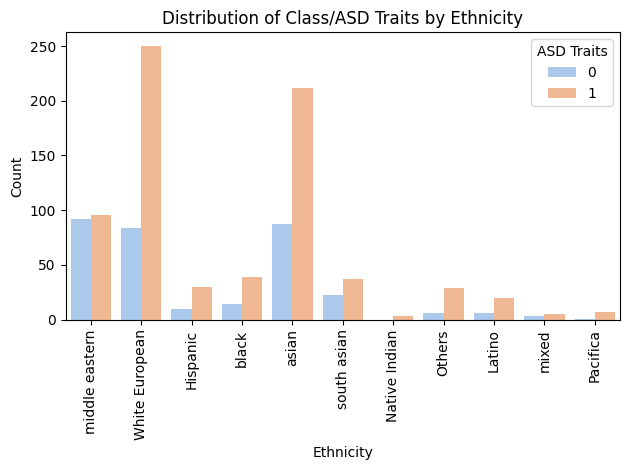

In [198]:
sns.countplot(data=dataADT, x='Ethnicity', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

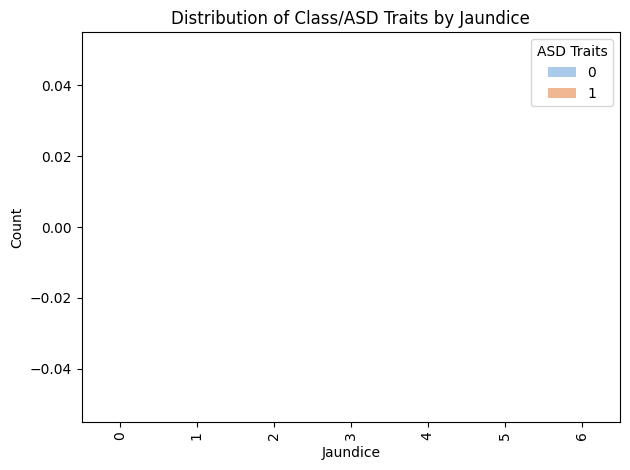

In [199]:
sns.countplot(data=dataADT, x='Jaundice', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Jaundice')
plt.xlabel('Jaundice')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

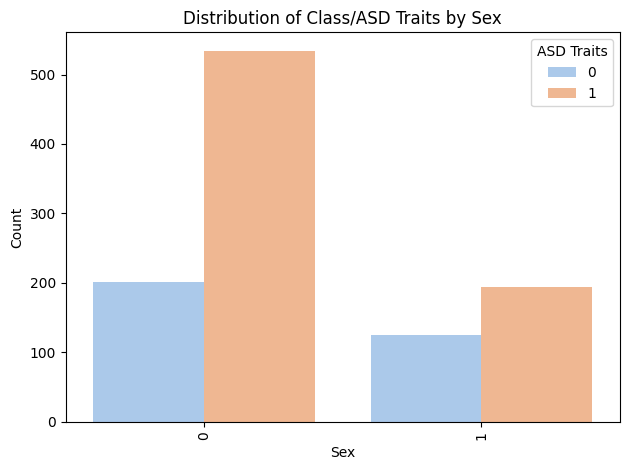

In [200]:
sns.countplot(data=dataADT, x='Sex', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()

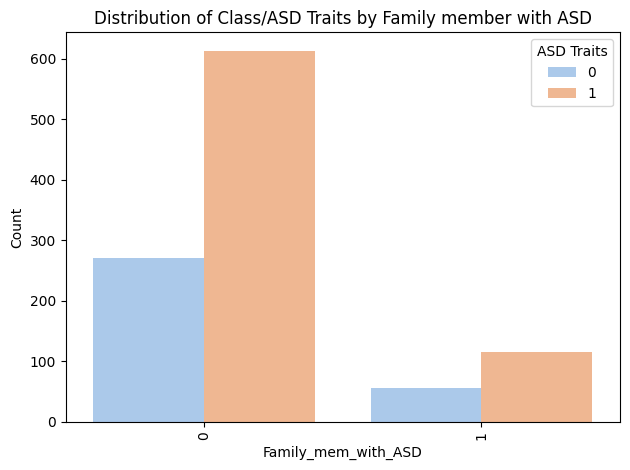

In [201]:
sns.countplot(data=dataADT, x='Family_mem_with_ASD', hue='Class/ASD Traits ', palette='pastel')
plt.title('Distribution of Class/ASD Traits by Family member with ASD')
plt.xlabel('Family_mem_with_ASD')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.legend(title='ASD Traits', loc='upper right')
plt.tight_layout()
plt.show()